In [1]:
import pickle
from typing import Optional
from functools import partial

import jax
import optax
import optuna
import equinox as eqx
import jax.numpy as jnp
import snnax.snn as snn
import jax.random as jrandom
import optuna.storages.journal
from chex import Array, PRNGKey
from tqdm import trange

from eleanor.models import Heracles
from eleanor.datasets import shuffle, loadBraille
from eleanor.weight_quantization import QuantizedLinear

In [2]:
import os
from pathlib import Path
import pandas as pd

model_name = ["Heracles", "LIF"]
quantization = "3"

df = pd.DataFrame()

for model in model_name:
    logdir = f"results/{quantization}bit_{model}"
    for filename in os.listdir(logdir):
        f = os.path.join(logdir, filename)
        # checking if it is a file
        if os.path.isfile(f):
            seed = int(Path(f).stem)
            accuracy = jnp.load(f)
            nepochs = len(accuracy)
            epochs = jnp.arange(nepochs)
            seeds = [seed] * nepochs
            models = [model] * nepochs
            df = pd.concat(
                [
                    df,
                    pd.DataFrame(
                        {
                            "Accuracy": accuracy,
                            "Epoch": epochs,
                            "Seed": seeds,
                            "Model": models,
                        }
                    ),
                ],
                ignore_index=True,
            )

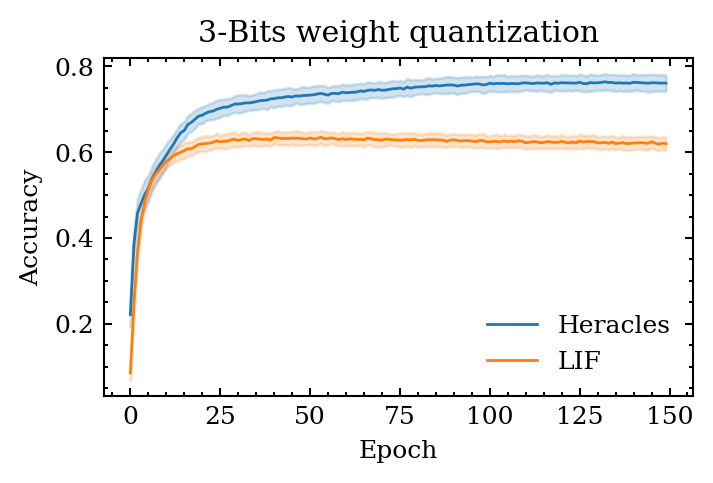

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

with mpl.style.context("boilerplot.ieeetran"):
    fig, axs = plt.subplots(figsize=[3.45, 2.3], dpi=200, constrained_layout=True)
    sns.lineplot(df, x="Epoch", y="Accuracy", hue="Model", errorbar="sd", ax=axs)
    plt.title("3-Bits weight quantization")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()
    # plt.savefig('results/HeraclesLIF.svg')

In [7]:
from optuna.visualization.matplotlib import plot_terminator_improvement, plot_edf
from optuna.visualization._edf import _get_edf_info
quantization = "3"
studies = []
for model in model_name:
    storage = optuna.storages.RDBStorage("sqlite:///bruno.db")
    study = optuna.load_study(
        storage=storage,
        study_name=f"{quantization}bit {model}"
    )
    studies.append(study)

In [13]:
with mpl.style.context("boilerplot.ieeetran"):
    fig, ax = plt.subplots(figsize=[3.45, 2.3], dpi=200, constrained_layout=True)
    ax.set_title("Empirical Distribution Function Plot")
    ax.set_xlabel("Objective Value")
    ax.set_ylabel("Cumulative Probability")
    ax.set_ylim(0, 1)
    cmap = plt.get_cmap("tab10")  # Use tab20 colormap for multiple line plots.

    info = _get_edf_info(studies, None, "Accuracy")
    edf_lines = info.lines

    for i, (study_name, y_values) in enumerate(edf_lines):
        ax.plot(info.x_values, y_values, color=cmap(i), alpha=0.7, label=study_name)

    if len(edf_lines) >= 2:
        ax.legend()
    plt.savefig('EDF.svg')